In [1]:
from pathlib import Path
notebook_dir = Path().resolve()
data_path = notebook_dir.parent / "DataSet" / "secom.csv"
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
import statsmodels.api as sm
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV, RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix, precision_recall_curve, roc_auc_score, make_scorer, accuracy_score, f1_score, r2_score, mean_absolute_error, mutual_info_score, roc_curve, zero_one_loss
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import LinearSVC, SVC
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import BaseEstimator, TransformerMixin, clone
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter, defaultdict


Text(0.5, 1.0, 'Weekly samples & defect ratio')

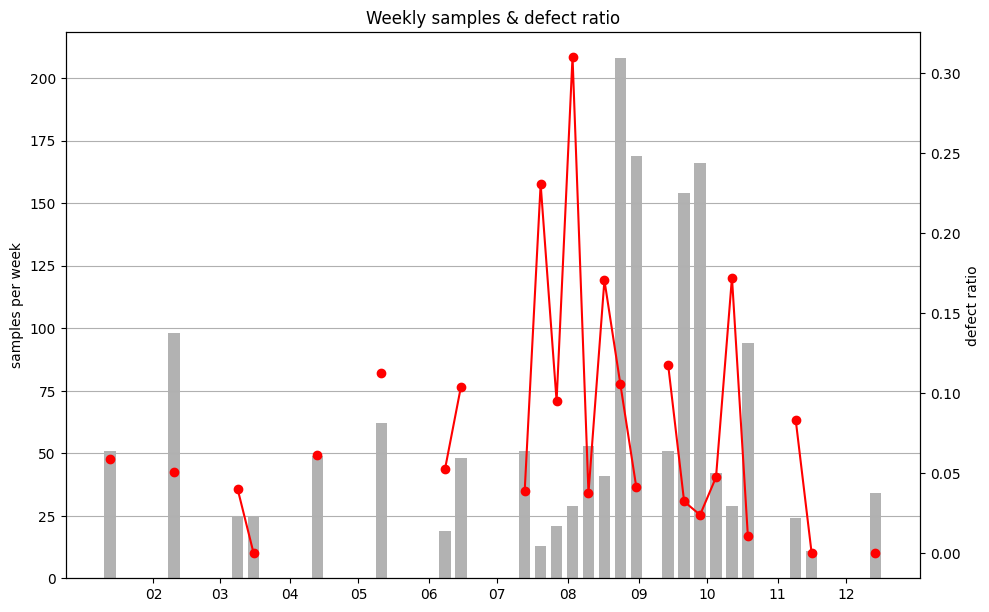

In [2]:
secom = pd.read_csv(data_path, sep='\t')
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

time_dt = pd.to_datetime(secom['Time'])
df = pd.DataFrame({'Time':time_dt, 'y':y}).sort_values('Time').set_index('Time')

w = df['y'].resample('W') # W means the end of the date
cnt, rate = w.size(), w.mean() # rate means 1/0 (fail/pass) less is better

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(cnt.index, cnt.values, width=5, alpha=0.3, color='k')
ax1.set_ylabel('samples per week')
ax1.grid(True, axis='y')

ax2 = ax1.twinx()
ax2.plot(rate.index, rate.values, marker='o', color='r')
ax2.set_ylabel('defect ratio')
months = pd.date_range(rate.index.min().normalize(),
                       rate.index.max().normalize(), freq='MS') 
ax2.set_xticks(months)
ax2.set_xticklabels([d.strftime('%m') for d in months], rotation=0, ha='center')

plt.tight_layout()
plt.title('Weekly samples & defect ratio')
